# Laboratorio #2 — Redes Neuronales Convolucionales

**Curso:** CC3092 — Deep Learning y Sistemas Inteligentes
**Estudiante:** Ian Cumes  **Carné:** 23236
**Dataset:** MNIST (clasificación multiclase de dígitos escritos a mano, 0–9)
**Repositorio:** https://github.com/iancumes/Lab2DeepLearning

---

## Contenido

1. [Configuración del entorno](#setup)
2. [Exploración y preparación de los datos](#seccion2)
3. [Investigación: capas de PyTorch para la CNN](#seccion3)
4. [Construcción y entrenamiento de las arquitecturas](#seccion4)
5. [Comparación de arquitecturas](#seccion5)
6. [Discusión y análisis](#seccion6)

> **Nota sobre la ejecución.** Las 12 iteraciones de entrenamiento se corren desde
> `src/experiments.py` y se guardan en `results/iterations.json` conforme terminan.
> Este notebook carga esos resultados si ya existen; si no, los entrena en el momento.
> Así el notebook es reproducible de punta a punta sin obligar a re-entrenar unas 2 horas
> de CPU cada vez que se abre.

<a id="setup"></a>
## 1. Configuración del entorno

Se fija la semilla global en **23236** (el carné) para que toda la búsqueda sea reproducible
y para que las diferencias entre iteraciones sean atribuibles al hiperparámetro que cambia,
no a una inicialización distinta.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from torch import nn

# Permite importar el paquete src/ tanto si el notebook se abre desde notebooks/
# como desde la raiz del repositorio.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import experiments, figures, report_data
from src.data import build_dataloaders, class_distribution, raw_datasets
from src.models import CNN, MLP, build_model, count_parameters
from src.train import SEED, evaluate, set_seed

torch.set_num_threads(4)
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

print(f"PyTorch {torch.__version__} | dispositivo: {DEVICE} | semilla: {SEED}")

PyTorch 2.13.0+cu130 | dispositivo: cpu | semilla: 23236


<a id="seccion2"></a>
## 2. Exploración y preparación de los datos

Se carga MNIST desde `torchvision.datasets.MNIST`. Primero se inspecciona **sin normalizar**
(solo `ToTensor()`, que ya escala los enteros `[0, 255]` a flotantes `[0, 1]`) para poder
responder honestamente las preguntas sobre el rango de los píxeles.

In [2]:
train_raw, test_raw = raw_datasets()

print(f"Observaciones de entrenamiento : {len(train_raw):,}")
print(f"Observaciones de test          : {len(test_raw):,}")
print(f"Total                          : {len(train_raw) + len(test_raw):,}")
print(f"Clases                         : {len(train_raw.classes)} -> {train_raw.classes}")

img, label = train_raw[0]
print(f"\nShape de una imagen (C, H, W)  : {tuple(img.shape)}")
print(f"dtype                          : {img.dtype}")
print(f"Rango tras ToTensor()          : [{img.min():.3f}, {img.max():.3f}]")
print(f"Rango del tensor crudo (uint8) : [{train_raw.data.min()}, {train_raw.data.max()}]")

Observaciones de entrenamiento : 60,000
Observaciones de test          : 10,000
Total                          : 70,000
Clases                         : 10 -> ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

Shape de una imagen (C, H, W)  : (1, 28, 28)
dtype                          : torch.float32
Rango tras ToTensor()          : [0.000, 1.000]
Rango del tensor crudo (uint8) : [0, 255]


### 2.1 ¿Cuántas observaciones y cuántas clases? ¿Están balanceadas?

In [3]:
counts_train = class_distribution(train_raw.targets.numpy())
counts_test = class_distribution(test_raw.targets.numpy())

balance = pd.DataFrame(
    {"Train": pd.Series(counts_train), "Test": pd.Series(counts_test)}
).rename_axis("Dígito")
balance["% Train"] = balance["Train"] / balance["Train"].sum() * 100

n = balance["Train"]
print(f"Clase mas frecuente : {n.idxmax()} con {n.max():,} ({n.max()/n.sum()*100:.2f}%)")
print(f"Clase menos frecuente: {n.idxmin()} con {n.min():,} ({n.min()/n.sum()*100:.2f}%)")
print(f"Razon max/min        : {n.max()/n.min():.3f}  (1.000 seria balance perfecto)")
print(f"Desviacion respecto al 10% ideal: +-{(balance['% Train'] - 10).abs().max():.2f} puntos porcentuales")
balance

Clase mas frecuente : 1 con 6,742 (11.24%)
Clase menos frecuente: 5 con 5,421 (9.04%)
Razon max/min        : 1.244  (1.000 seria balance perfecto)
Desviacion respecto al 10% ideal: +-1.24 puntos porcentuales


,Train,Test,% Train
Dígito,,,
0,5923,980,9.871667
1,6742,1135,11.236667
2,5958,1032,9.930000
3,6131,1010,10.218333
4,5842,982,9.736667
5,5421,892,9.035000
6,5918,958,9.863333
7,6265,1028,10.441667
8,5851,974,9.751667


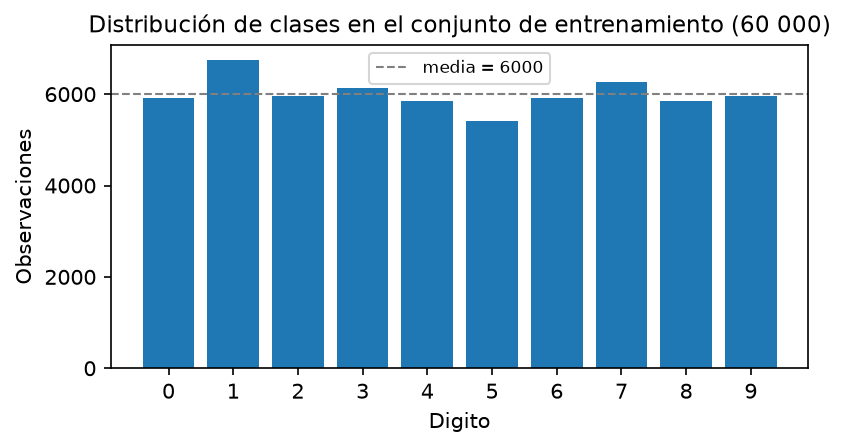

In [4]:
fig_dist = figures.plot_class_distribution(
    counts_train, "Distribución de clases en el conjunto de entrenamiento (60 000)"
)
display(Image(str(fig_dist)))

**Respuesta.** El dataset tiene **70 000 imágenes** en total (60 000 de entrenamiento + 10 000 de test)
y **10 clases** (los dígitos 0–9).

Las clases están **aproximadamente balanceadas, pero no perfectamente**: van del ~9.0 % (dígito 5,
la clase minoritaria) al ~11.2 % (dígito 1, la mayoritaria), con una razón máx/mín de ≈1.24. Ese
desbalance es lo bastante leve como para **no** requerir remuestreo ni pesos por clase, pero sí
justifica dos decisiones que se toman más adelante:

- usar métricas **macro** (promedian por clase, sin dejar que las clases grandes dominen el número), y
- hacer el split train/validación **estratificado**, para que la proporción de cada dígito se conserve.

### 2.2 Dimensión de las imágenes y rango de los píxeles

In [5]:
sample = train_raw.data[:2000].float()
print(f"Dimension              : 28 x 28 pixeles, 1 canal (escala de grises)")
print(f"Features al aplanar    : {28 * 28} valores por imagen")
print(f"Rango original (uint8) : [0, 255]  -> enteros")
print(f"Rango tras ToTensor()  : [0, 1]    -> float32")
print(f"\nMedia de los pixeles   : {sample.div(255).mean():.4f}")
print(f"Desv. estandar         : {sample.div(255).std():.4f}")
print(f"Proporcion de pixeles en 0 (fondo): {(sample == 0).float().mean() * 100:.1f}%")

Dimension              : 28 x 28 pixeles, 1 canal (escala de grises)
Features al aplanar    : 784 valores por imagen
Rango original (uint8) : [0, 255]  -> enteros
Rango tras ToTensor()  : [0, 1]    -> float32

Media de los pixeles   : 0.1302
Desv. estandar         : 0.3077
Proporcion de pixeles en 0 (fondo): 81.0%


### 2.3 ¿Es necesario normalizar los valores de los píxeles?

**Sí.** `ToTensor()` ya lleva los píxeles de `[0, 255]` a `[0, 1]`, y ese solo paso es
imprescindible: con entradas en el orden de las centenas los productos punto de la primera capa
salen enormes, las activaciones se saturan y los gradientes se disparan.

Además se aplica una **estandarización** `Normalize(mean, std)` que centra los datos en 0 con
desviación 1. Esto importa porque **el 80 % de los píxeles de MNIST son fondo negro (valor 0)**:
sin centrar, la entrada media está muy cerca de 0.13 en vez de 0, lo que introduce un sesgo
sistemático en todas las activaciones y hace que el descenso de gradiente zigzaguee en vez de
avanzar recto hacia el mínimo.

Detalle metodológico: la media y la desviación se calculan **únicamente sobre el split de
entrenamiento**. Calcularlas sobre el dataset completo filtraría información de validación y de
test hacia el preprocesamiento (*data leakage*).

In [6]:
loaders, meta = build_dataloaders(batch_size=128)

print(f"Entrenamiento : {meta['n_train']:,} imagenes")
print(f"Validacion    : {meta['n_val']:,} imagenes")
print(f"Test          : {meta['n_test']:,} imagenes  (intacto hasta la evaluacion final)")
print(f"\nMedia calculada sobre train : {meta['mean']:.4f}")
print(f"Desv. estandar sobre train  : {meta['std']:.4f}")
print("(coinciden con los valores canonicos de MNIST: 0.1307 y 0.3081)")

xb, yb = next(iter(loaders["train"]))
print(f"\nBatch de entrenamiento: {tuple(xb.shape)}  etiquetas: {tuple(yb.shape)}")
print(f"Rango tras normalizar : [{xb.min():.3f}, {xb.max():.3f}]  media: {xb.mean():.4f}")

Entrenamiento : 54,000 imagenes
Validacion    : 6,000 imagenes
Test          : 10,000 imagenes  (intacto hasta la evaluacion final)

Media calculada sobre train : 0.1306
Desv. estandar sobre train  : 0.3081
(coinciden con los valores canonicos de MNIST: 0.1307 y 0.3081)



Batch de entrenamiento: (128, 1, 28, 28)  etiquetas: (128,)
Rango tras normalizar : [-0.424, 2.822]  media: -0.0006


### 2.4 Visualización de ejemplos con su etiqueta

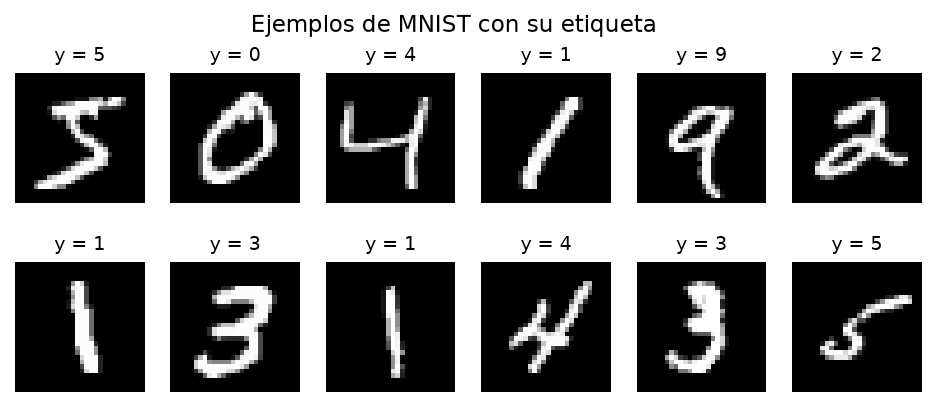

In [7]:
fig_samples = figures.plot_samples(train_raw, n=12)
display(Image(str(fig_samples)))

### 2.5 División en entrenamiento y validación

Se separan **6 000 imágenes (10 %)** del conjunto de entrenamiento para validación, de forma
**estratificada** con `random_state=23236`. El conjunto de test de 10 000 imágenes queda sin tocar
hasta la evaluación final del punto 4: toda la selección de hiperparámetros se hace mirando
**solo validación**.

In [8]:
split_df = pd.DataFrame({
    "Train": pd.Series(meta["train_class_counts"]),
    "Val": pd.Series(meta["val_class_counts"]),
    "Test": pd.Series(meta["test_class_counts"]),
}).rename_axis("Dígito")
split_df.loc["Total"] = split_df.sum()
split_df["% Val"] = (split_df["Val"] / split_df[["Train", "Val"]].sum(axis=1) * 100).round(2)
split_df

,Train,Val,Test,% Val
Dígito,,,,
0,5331,592,980,9.99
1,6068,674,1135,10.00
2,5362,596,1032,10.00
3,5518,613,1010,10.00
4,5258,584,982,10.00
5,4879,542,892,10.00
6,5326,592,958,10.00
7,5638,627,1028,10.01
8,5266,585,974,10.00


<a id="seccion3"></a>
## 3. Investigación: capas de PyTorch para la CNN

Para cada capa se describe su propósito y sus parámetros más relevantes, y se acompaña de una
demostración ejecutable que muestra **cómo transforma las dimensiones del tensor** y cuántos
parámetros aporta. Ver el efecto sobre los shapes es lo que hace concreto el papel de cada capa.

### 3.1 `nn.Conv2d` — extracción de patrones locales

**Propósito.** Desliza filtros (*kernels*) aprendibles sobre la imagen; cada filtro produce un mapa
de activación que responde fuerte donde encuentra el patrón que aprendió a detectar (bordes,
esquinas, curvas). Es la capa que define a una CNN.

**Parámetros más relevantes:**

| Parámetro | Qué controla |
|---|---|
| `in_channels` | Canales de entrada (1 en MNIST por ser escala de grises) |
| `out_channels` | Número de filtros = número de mapas de activación de salida |
| `kernel_size` | Tamaño de la ventana (3×3 aquí). Kernels chicos apilados > un kernel grande |
| `stride` | Paso del deslizamiento; >1 submuestrea |
| `padding` | Ceros en el borde. `padding = kernel_size // 2` conserva el tamaño espacial |
| `dilation` | Separa los elementos del kernel para ampliar el campo receptivo sin más parámetros |
| `bias` | Sesgo por filtro. Se suele desactivar cuando le sigue un `BatchNorm2d` |

Fórmula del tamaño de salida: `H_out = (H_in + 2·padding − dilation·(kernel−1) − 1) / stride + 1`.

**Conteo de parámetros:** `out_channels × (in_channels × k × k) + out_channels`. Nótese que **no
depende del tamaño de la imagen** — ese es justamente el origen del ahorro frente a una capa densa.

In [9]:
x = torch.randn(8, 1, 28, 28)  # batch de 8 imagenes de MNIST

conv = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
out = conv(x)
print(f"Conv2d(1, 32, k=3, padding=1): {tuple(x.shape)} -> {tuple(out.shape)}")
print(f"  parametros: 32*(1*3*3) + 32 = {count_parameters(conv):,}")

# Comparacion directa con la capa densa equivalente en numero de salidas
dense = nn.Linear(28 * 28, 32)
print(f"\nLinear(784, 32) [equivalente denso]: {count_parameters(dense):,} parametros")
print(f"  -> la convolucion usa {count_parameters(dense) / count_parameters(conv):.1f}x menos parametros")
print(f"  -> y ademas produce 32 mapas de 28x28 en vez de 32 numeros sueltos")

# El padding controla si se conserva el tamano espacial
print(f"\nSin padding: {tuple(nn.Conv2d(1, 32, 3)(x).shape)}  (28 -> 26, se pierde el borde)")
print(f"stride=2   : {tuple(nn.Conv2d(1, 32, 3, stride=2, padding=1)(x).shape)}  (submuestrea)")

Conv2d(1, 32, k=3, padding=1): (8, 1, 28, 28) -> (8, 32, 28, 28)
  parametros: 32*(1*3*3) + 32 = 320

Linear(784, 32) [equivalente denso]: 25,120 parametros
  -> la convolucion usa 78.5x menos parametros
  -> y ademas produce 32 mapas de 28x28 en vez de 32 numeros sueltos

Sin padding: (8, 32, 26, 26)  (28 -> 26, se pierde el borde)
stride=2   : (8, 32, 14, 14)  (submuestrea)


### 3.2 `nn.MaxPool2d` y `nn.AvgPool2d` — submuestreo

**Propósito común.** Reducen la resolución espacial. Esto cumple tres funciones: baja el costo
computacional, **amplía el campo receptivo** de las capas siguientes, y da cierta invarianza a
pequeñas traslaciones (si el trazo se corre un píxel, la ventana probablemente devuelve lo mismo).
**Ninguna de las dos tiene parámetros entrenables.**

**La diferencia.** `MaxPool2d` se queda con el **valor máximo** de la ventana; `AvgPool2d` con el
**promedio**. La intuición habitual dice que en imágenes como MNIST —trazos claros sobre fondo
negro— el máximo debería ganar, porque preserva el trazo intacto mientras que el promedio lo
**diluye** al mezclarlo con el fondo que lo rodea.

Conviene señalar desde ya que **esa intuición no se sostuvo**: en la iteración C3 el cambio a
`AvgPool2d` *mejoró* el F1 de validación. Una lectura plausible es que el promedio conserva cuánta
señal había en la región y no solo su pico, lo que da una estimación menos frágil ante un píxel
brillante aislado. Es un buen recordatorio de por qué la elección se decide midiendo y no razonando.

**Parámetros más relevantes:** `kernel_size` (tamaño de la ventana), `stride` (por defecto igual a
`kernel_size`, es decir ventanas sin solape), `padding`, y `ceil_mode` (redondea hacia arriba el
tamaño de salida). `AvgPool2d` añade `count_include_pad`, que decide si los ceros del padding
cuentan en el promedio.

In [10]:
feature_map = conv(x)  # (8, 32, 28, 28)
mx = nn.MaxPool2d(2)(feature_map)
av = nn.AvgPool2d(2)(feature_map)
print(f"MaxPool2d(2): {tuple(feature_map.shape)} -> {tuple(mx.shape)}   (parametros: {count_parameters(nn.MaxPool2d(2))})")
print(f"AvgPool2d(2): {tuple(feature_map.shape)} -> {tuple(av.shape)}   (parametros: {count_parameters(nn.AvgPool2d(2))})")

# Demostracion numerica de la diferencia sobre un trazo aislado
patch = torch.tensor([[[[0., 0., 0., 0.],
                        [0., 9., 0., 0.],
                        [0., 0., 0., 0.],
                        [0., 0., 0., 8.]]]])
print("\nVentana 2x2 sobre un 'trazo' de intensidad 9 rodeado de fondo:")
print(f"  max : {nn.MaxPool2d(2)(patch).flatten().tolist()}  <- conserva la intensidad del trazo")
print(f"  avg : {nn.AvgPool2d(2)(patch).flatten().tolist()}  <- la diluye a 1/4")

MaxPool2d(2): (8, 32, 28, 28) -> (8, 32, 14, 14)   (parametros: 0)
AvgPool2d(2): (8, 32, 28, 28) -> (8, 32, 14, 14)   (parametros: 0)

Ventana 2x2 sobre un 'trazo' de intensidad 9 rodeado de fondo:
  max : [9.0, 0.0, 0.0, 8.0]  <- conserva la intensidad del trazo
  avg : [2.25, 0.0, 0.0, 2.0]  <- la diluye a 1/4


### 3.3 `nn.BatchNorm2d` — normalización por canal

**Propósito.** Normaliza cada canal usando la media y la varianza del *batch* y luego lo reescala
con dos parámetros aprendibles por canal (`gamma`, `beta`). Al mantener las activaciones en un rango
estable capa a capa, hace que la superficie de pérdida esté mejor condicionada: se puede usar un
learning rate más alto y la red converge en menos epochs. Aporta además una regularización leve,
porque las estadísticas del batch introducen ruido que varía entre pasadas.

**Parámetros más relevantes:** `num_features` (número de canales, debe coincidir con `out_channels`
de la convolución anterior), `eps` (estabilidad numérica), `momentum` (con qué rapidez se actualizan
las estadísticas móviles), `affine` (si aprende `gamma`/`beta`), `track_running_stats` (guarda medias
móviles para usarlas en inferencia).

**Detalle importante:** se comporta distinto en `train()` que en `eval()` — en entrenamiento usa las
estadísticas del batch, en evaluación las móviles acumuladas. Por eso el bucle de entrenamiento
llama explícitamente a `model.train()` y `model.eval()`.

In [11]:
bn = nn.BatchNorm2d(32)
normed = bn(feature_map)
print(f"BatchNorm2d(32): {tuple(feature_map.shape)} -> {tuple(normed.shape)}  (shape intacto)")
print(f"  parametros entrenables: 32 gamma + 32 beta = {count_parameters(bn)}")
print(f"\nAntes  -> media {feature_map.mean():+.4f}, std {feature_map.std():.4f}")
print(f"Despues -> media {normed.mean():+.4f}, std {normed.std():.4f}  (centrado y escalado)")

BatchNorm2d(32): (8, 32, 28, 28) -> (8, 32, 28, 28)  (shape intacto)
  parametros entrenables: 32 gamma + 32 beta = 64

Antes  -> media +0.0205, std 0.6158
Despues -> media -0.0000, std 1.0000  (centrado y escalado)


### 3.4 `nn.Flatten` — puente entre la parte convolucional y el clasificador

**Propósito.** Convierte el tensor `(N, C, H, W)` en `(N, C·H·W)` para poder alimentar capas
`Linear`. No tiene parámetros ni realiza cómputo real: solo reinterpreta la disposición de los datos.

**Parámetros:** `start_dim` (por defecto 1, para no aplanar la dimensión de batch) y `end_dim`.

Es también la **primera capa del MLP**: ahí es donde se pierde la estructura espacial, y esa pérdida
es exactamente la desventaja estructural que la CNN evita.

In [12]:
flat = nn.Flatten()(mx)
print(f"Flatten: {tuple(mx.shape)} -> {tuple(flat.shape)}   ({mx.shape[1]}x{mx.shape[2]}x{mx.shape[3]} = {flat.shape[1]})")
print(f"parametros: {count_parameters(nn.Flatten())}")
print(f"\nEn el MLP: {tuple(x.shape)} -> {tuple(nn.Flatten()(x).shape)}")
print("  ^ aqui se pierde la nocion de que dos pixeles eran vecinos")

Flatten: (8, 32, 14, 14) -> (8, 6272)   (32x14x14 = 6272)
parametros: 0

En el MLP: (8, 1, 28, 28) -> (8, 784)
  ^ aqui se pierde la nocion de que dos pixeles eran vecinos


### 3.5 `nn.CrossEntropyLoss` — función de pérdida

**Propósito.** Es la pérdida estándar de clasificación multiclase. Combina `log_softmax` y
`NLLLoss` en una sola operación numéricamente estable (evita el desbordamiento de calcular el
exponencial y luego el logaritmo por separado).

**Consecuencia práctica clave:** el modelo debe entregar **logits crudos**. Poner un `Softmax` en la
última capa es un error frecuente — aplicaría la operación dos veces y aplanaría los gradientes.
Por eso ambas arquitecturas terminan en un `nn.Linear(..., 10)` sin activación.

**Parámetros más relevantes:** `weight` (pondera clases, útil con desbalance fuerte —aquí no hace
falta), `reduction` (`'mean'` por defecto), `label_smoothing` (suaviza las etiquetas duras para
reducir el exceso de confianza), `ignore_index`.

In [13]:
criterion = nn.CrossEntropyLoss()
logits = torch.tensor([[3.0, 0.5, 0.2], [0.1, 0.2, 4.0]])
targets = torch.tensor([0, 2])
print(f"Loss con predicciones correctas y confiadas: {criterion(logits, targets):.4f}")
print(f"Loss con las etiquetas invertidas          : {criterion(logits, torch.tensor([2, 0])):.4f}")

# Equivalencia con log_softmax + NLLLoss
manual = nn.NLLLoss()(torch.log_softmax(logits, dim=1), targets)
print(f"\nlog_softmax + NLLLoss = {manual:.6f}  ==  CrossEntropyLoss = {criterion(logits, targets):.6f}")
print(f"Loss de un modelo aleatorio con 10 clases: ln(10) = {np.log(10):.4f} (referencia inicial esperada)")

Loss con predicciones correctas y confiadas: 0.0876
Loss con las etiquetas invertidas          : 3.4376

log_softmax + NLLLoss = 0.087647  ==  CrossEntropyLoss = 0.087647
Loss de un modelo aleatorio con 10 clases: ln(10) = 2.3026 (referencia inicial esperada)


### 3.6 Tensor, campo receptivo y por qué la CNN usa menos parámetros

#### Tensor

Un **tensor** es el arreglo multidimensional que PyTorch usa para *todo*: datos, parámetros y
gradientes. Es más que un `ndarray` de NumPy porque además de los valores lleva:

- el **dtype** y el **dispositivo** (CPU/GPU) en que reside,
- una bandera `requires_grad` y, si está activa, el **grafo de operaciones** que lo produjo, que es
  lo que permite a autograd calcular gradientes recorriéndolo hacia atrás.

En este laboratorio los shapes relevantes son: un batch de imágenes `(N, 1, 28, 28)`, el mismo batch
aplanado para el MLP `(N, 784)` y la salida de ambos modelos `(N, 10)`.

#### Campo receptivo (*receptive field*)

Es la región de la **imagen de entrada** que influye en el valor de una sola activación de una capa
profunda. Crece de forma incremental:

```
RF_out = RF_in + (k − 1) · jump        jump_out = jump_in · stride
```

donde `jump` es el producto de los strides acumulados hasta esa capa. La consecuencia es la clave del
diseño de una CNN: **apilar capas aumenta el campo receptivo sin aumentar el tamaño del kernel**. Las
primeras capas ven trazos locales de pocos píxeles; las últimas abarcan buena parte del dígito y ya
pueden reconocer su forma global.

In [14]:
def receptive_field_trace(n_blocks, k=3):
    """Traza el crecimiento del campo receptivo bloque por bloque."""
    rf, jump, rows = 1, 1, []
    for b in range(1, n_blocks + 1):
        rf += (k - 1) * jump
        rows.append({"Capa": f"Conv2d {b} (k={k})", "Campo receptivo": f"{rf}x{rf}", "Jump": jump})
        rf += (2 - 1) * jump
        jump *= 2
        rows.append({"Capa": f"MaxPool2d {b} (2x2)", "Campo receptivo": f"{rf}x{rf}", "Jump": jump})
    return pd.DataFrame(rows)

print("Crecimiento del campo receptivo en una CNN de 3 bloques sobre imagenes de 28x28:")
display(receptive_field_trace(3))
print(f"CNN de 2 bloques -> campo receptivo final: {CNN(channels=(32, 64)).receptive_field()} px")
print(f"CNN de 3 bloques -> campo receptivo final: {CNN(channels=(32, 64, 128)).receptive_field()} px")

Crecimiento del campo receptivo en una CNN de 3 bloques sobre imagenes de 28x28:


,Capa,Campo receptivo,Jump
0,Conv2d 1 (k=3),3x3,1
1,MaxPool2d 1 (2x2),4x4,2
2,Conv2d 2 (k=3),8x8,2
3,MaxPool2d 2 (2x2),10x10,4
4,Conv2d 3 (k=3),18x18,4
5,MaxPool2d 3 (2x2),22x22,8


CNN de 2 bloques -> campo receptivo final: 10 px
CNN de 3 bloques -> campo receptivo final: 22 px


#### ¿Por qué una CNN necesita menos parámetros que un MLP equivalente?

Por dos mecanismos que actúan a la vez:

1. **Conectividad local.** Cada neurona convolucional solo mira una ventana de `k×k` píxeles, no los
   784. Una capa densa conecta *todo con todo*; la convolución explota el hecho de que en una imagen
   los píxeles informativos son los vecinos.
2. **Pesos compartidos.** El *mismo* filtro se aplica en todas las posiciones de la imagen. Detectar
   un borde vertical en la esquina superior izquierda usa exactamente los mismos 9 pesos que
   detectarlo en el centro. El MLP, en cambio, tiene que aprender el patrón **por separado en cada
   posición**, y por eso su costo en parámetros escala con la resolución.

Hay una tercera consecuencia, más importante que el ahorro: el peso compartido es un **sesgo
inductivo** correcto para imágenes. La CNN no solo usa menos parámetros — usa parámetros que
*generalizan* mejor, porque incorporan de fábrica la suposición de que un patrón significa lo mismo
esté donde esté.

In [15]:
comp = []
for name, layer, desc in [
    ("Conv2d(1, 32, k=3)", nn.Conv2d(1, 32, 3, padding=1), "32 mapas de 28x28, pesos compartidos"),
    ("Linear(784, 32)", nn.Linear(784, 32), "32 escalares, un peso por pixel"),
    ("Conv2d(32, 64, k=3)", nn.Conv2d(32, 64, 3, padding=1), "64 mapas, independiente del tamano"),
    ("Linear(784, 256)", nn.Linear(784, 256), "capa oculta tipica de un MLP"),
]:
    comp.append({"Capa": name, "Parámetros": count_parameters(layer), "Qué produce": desc})
display(pd.DataFrame(comp).style.format({"Parámetros": "{:,}"}))

mlp_demo = MLP(hidden_sizes=(256, 128))
cnn_demo = CNN(channels=(32, 64), use_bn=True)
print(f"\nMLP (784-256-128-10)          : {count_parameters(mlp_demo):,} parametros")
print(f"CNN (32-64 conv + FC 128)     : {count_parameters(cnn_demo):,} parametros")
print(f"\nDonde estan los parametros de la CNN:")
print(f"  bloques convolucionales : {count_parameters(cnn_demo.features):,}  ({count_parameters(cnn_demo.features)/count_parameters(cnn_demo)*100:.1f}%)")
print(f"  clasificador denso      : {count_parameters(cnn_demo.classifier):,}  ({count_parameters(cnn_demo.classifier)/count_parameters(cnn_demo)*100:.1f}%)")
print("\n^ casi todo el costo de la CNN esta en la capa densa final, no en las convoluciones")

,Capa,Parámetros,Qué produce
0,"Conv2d(1, 32, k=3)",320,"32 mapas de 28x28, pesos compartidos"
1,"Linear(784, 32)","25,120","32 escalares, un peso por pixel"
2,"Conv2d(32, 64, k=3)","18,496","64 mapas, independiente del tamano"
3,"Linear(784, 256)","200,960",capa oculta tipica de un MLP



MLP (784-256-128-10)          : 235,146 parametros
CNN (32-64 conv + FC 128)     : 421,834 parametros

Donde estan los parametros de la CNN:
  bloques convolucionales : 19,008  (4.5%)
  clasificador denso      : 402,826  (95.5%)

^ casi todo el costo de la CNN esta en la capa densa final, no en las convoluciones


<a id="seccion4"></a>
## 4. Construcción y entrenamiento de las arquitecturas

### 4.1 Las dos arquitecturas

- **MLP** — recibe la imagen **aplanada** como vector de 784 valores.
  `Flatten → [Linear → (BatchNorm1d) → ReLU → (Dropout)] × n → Linear(10)`
- **CNN** — recibe la imagen como **tensor 2D** `(N, 1, 28, 28)` y usa **al menos dos capas
  convolucionales**. `[Conv2d → (BatchNorm2d) → ReLU → Pool(2)] × n → Flatten → Linear → (Dropout) → Linear(10)`

Ambas están parametrizadas por un diccionario de configuración (`src/models.py`), que es lo que
permite variar un solo hiperparámetro por iteración sin duplicar código.

In [16]:
mlp_example = MLP(hidden_sizes=(256, 128), dropout=0.3, use_bn=True)
cnn_example = CNN(channels=(32, 64), use_bn=True, dropout=0.25)

print("=== MLP ===")
print(mlp_example)
print(f"\nParametros entrenables: {count_parameters(mlp_example):,}")
print(f"Entrada {tuple(xb.shape)} -> salida {tuple(mlp_example(xb).shape)}")

print("\n=== CNN ===")
print(cnn_example)
print(f"\nParametros entrenables: {count_parameters(cnn_example):,}")
print(f"Entrada {tuple(xb.shape)} -> salida {tuple(cnn_example(xb).shape)}")
print(f"Campo receptivo final: {cnn_example.receptive_field()}x{cnn_example.receptive_field()} px")

=== MLP ===
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parametros entrenables: 235,914
Entrada (128, 1, 28, 28) -> salida (128, 10)

=== CNN ===
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

Entrada (128, 1, 28, 28) -> salida (128, 10)
Campo receptivo final: 10x10 px


### 4.2 Estrategia de búsqueda de hiperparámetros

Se realizan **12 iteraciones** (6 por arquitectura) siguiendo una búsqueda **sistemática**: se parte
de una baseline y cada iteración cambia **una sola variable** respecto de su iteración base. Esto
sacrifica cobertura del espacio a cambio de **atribución**: cuando una métrica sube o baja, se sabe
exactamente qué la movió. Una búsqueda aleatoria encontraría un modelo parecido pero no explicaría
nada.

La estructura resultante es un **árbol** más que una cadena: en la CNN, C3 (`AvgPool2d`) y C4
(`BatchNorm2d`) son dos ramas independientes que parten de C2, precisamente para no mezclar el
cambio de pooling con el de normalización. La columna `Base` de la tabla de plan indica de dónde
deriva cada iteración.

En cada iteración se registra lo que pide el enunciado: la configuración usada, la pérdida de
entrenamiento y validación **por epoch**, accuracy / precision / recall / F1 macro sobre validación,
el número total de parámetros entrenables y el tiempo de entrenamiento.

In [17]:
plan = pd.DataFrame([
    {"ID": c["id"], "Base": c.get("parent") or "—", "Arquitectura": c["arch"],
     "Variable aislada en esta iteración": c["change"], "Epochs": c["epochs"]}
    for c in experiments.all_configs()
])
plan.style.hide(axis="index")

ID,Base,Arquitectura,Variable aislada en esta iteración,Epochs
M1,—,MLP,"Baseline: 1 capa oculta de 128, SGD lr=0.01",10
M2,M1,MLP,Optimizador SGD -> Adam (lr=1e-3),10
M3,M2,MLP,Ancho de la capa oculta 128 -> 256,10
M4,M3,MLP,"Profundidad: 1 -> 2 capas ocultas (256, 128)",10
M5,M4,MLP,Regularizacion: + Dropout 0.3,10
M6,M5,MLP,Normalizacion: + BatchNorm1d,10
C1,—,CNN,"Baseline: 2 bloques conv (16, 32), MaxPool, Adam lr=1e-3",8
C2,C1,CNN,"Capacidad: canales (16,32) -> (32,64)",8
C3,C2,CNN,Pooling: MaxPool2d -> AvgPool2d,8
C4,C2,CNN,Normalizacion: + BatchNorm2d,8


In [18]:
# Ejecuta la busqueda. Si results/iterations.json ya existe, reutiliza lo calculado:
# cada iteracion se guarda apenas termina, de modo que la busqueda es reanudable.
iterations = experiments.run_search(device=DEVICE)
print(f"\nIteraciones completadas: {len(iterations)}")

Datos: train=54000 val=6000 test=10000


[M1] ya calculada, se omite


[M2] ya calculada, se omite


[M3] ya calculada, se omite


[M4] ya calculada, se omite


...

[C3] ya calculada, se omite


[C4] ya calculada, se omite


[C5] ya calculada, se omite


[C6] ya calculada, se omite



Iteraciones completadas: 12


### 4.3 Tabla de resultados de las 12 iteraciones

Todas las métricas son **macro** y están calculadas sobre el conjunto de **validación**.

In [19]:
it_table = report_data.iterations_table(iterations)
it_table.style.format({
    "Train loss": "{:.4f}", "Val loss": "{:.4f}",
    "Accuracy": "{:.2%}", "Precision": "{:.2%}", "Recall": "{:.2%}", "F1": "{:.2%}",
    "Params": "{:,}", "Tiempo (s)": "{:.1f}",
}).background_gradient(subset=["F1"], cmap="Greens").hide(axis="index")

ID,Base,Arq.,Cambio respecto a su base,Configuracion,Epochs,Train loss,Val loss,Accuracy,Precision,Recall,F1,Params,Tiempo (s)
M1,—,MLP,"Baseline: 1 capa oculta de 128, SGD lr=0.01","128, sgd lr=0.01",10,0.1987,0.2072,94.47%,94.43%,94.44%,94.43%,"101,770",89.5
M2,M1,MLP,Optimizador SGD -> Adam (lr=1e-3),"128, adam lr=0.001",10,0.0223,0.0959,97.40%,97.40%,97.38%,97.37%,"101,770",93.6
M3,M2,MLP,Ancho de la capa oculta 128 -> 256,"256, adam lr=0.001",10,0.0127,0.0889,97.85%,97.85%,97.83%,97.84%,"203,530",111.3
M4,M3,MLP,"Profundidad: 1 -> 2 capas ocultas (256, 128)","256-128, adam lr=0.001",10,0.0166,0.1032,97.72%,97.75%,97.66%,97.69%,"235,146",140.0
M5,M4,MLP,Regularizacion: + Dropout 0.3,"256-128, adam lr=0.001, drop=0.3",10,0.0568,0.0921,97.78%,97.79%,97.78%,97.77%,"235,146",126.1
M6,M5,MLP,Normalizacion: + BatchNorm1d,"256-128, adam lr=0.001, BN, drop=0.3",10,0.0552,0.0662,98.25%,98.23%,98.25%,98.24%,"235,914",137.8
C1,—,CNN,"Baseline: 2 bloques conv (16, 32), MaxPool, Adam lr=1e-3","16-32, pool=max, fc=128, adam lr=0.001",8,0.0128,0.0516,98.78%,98.77%,98.79%,98.78%,"206,922",149.5
C2,C1,CNN,"Capacidad: canales (16,32) -> (32,64)","32-64, pool=max, fc=128, adam lr=0.001",8,0.0110,0.0499,98.73%,98.73%,98.74%,98.73%,"421,642",230.2
C3,C2,CNN,Pooling: MaxPool2d -> AvgPool2d,"32-64, pool=avg, fc=128, adam lr=0.001",8,0.0162,0.0435,98.92%,98.93%,98.92%,98.92%,"421,642",229.7
C4,C2,CNN,Normalizacion: + BatchNorm2d,"32-64, pool=max, fc=128, adam lr=0.001, BN",8,0.0116,0.0537,98.62%,98.61%,98.64%,98.62%,"421,834",266.3


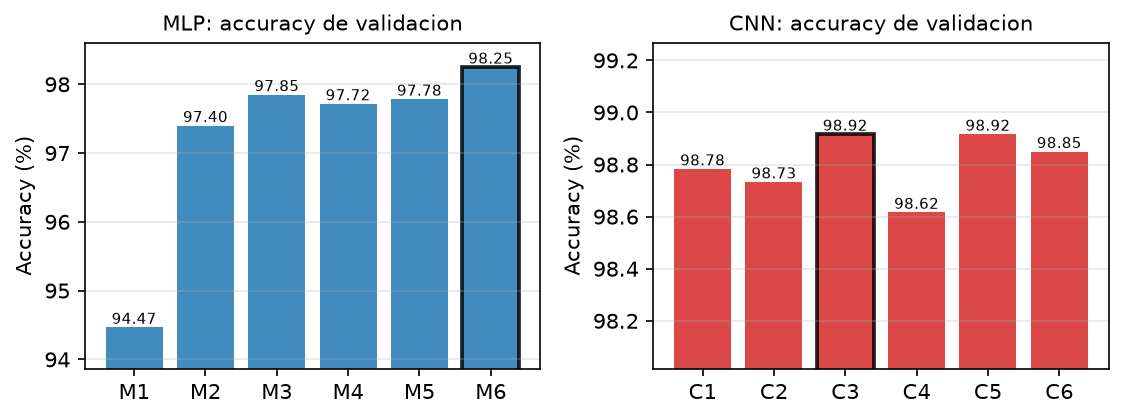

In [20]:
fig_val = figures.plot_val_metric_by_iteration(iterations)
display(Image(str(fig_val)))

### 4.4 Curvas de pérdida (las 6 iteraciones de cada arquitectura)

El enunciado pide graficar al menos 3 iteraciones por arquitectura; se grafican las 6. La **línea
continua** es la pérdida de entrenamiento y la **punteada** la de validación (escala logarítmica,
que hace visibles las diferencias en la cola).

**Cómo leerlas:** si ambas curvas bajan juntas, el modelo está aprendiendo bien. Si la de
entrenamiento sigue bajando mientras la de validación se aplana o **sube**, es **overfitting**: el
modelo memoriza el conjunto de entrenamiento. Si ambas se quedan altas y planas, es
**underfitting**: falta capacidad o falta optimización.

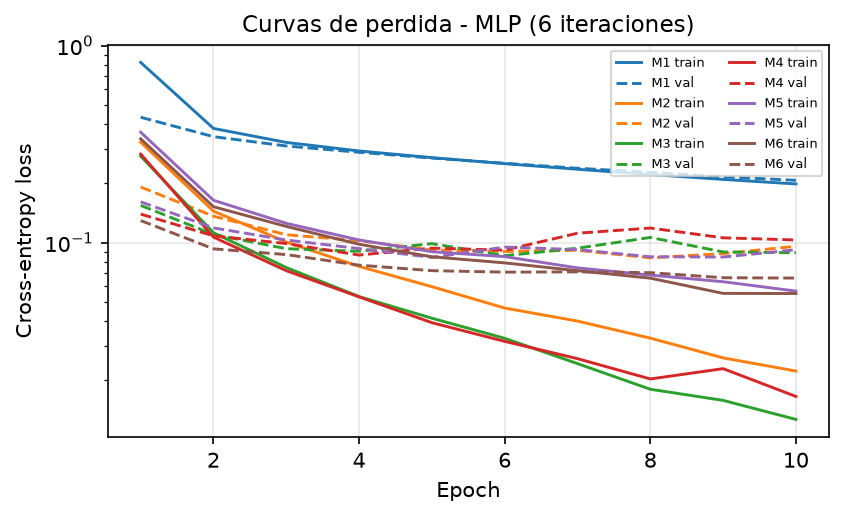

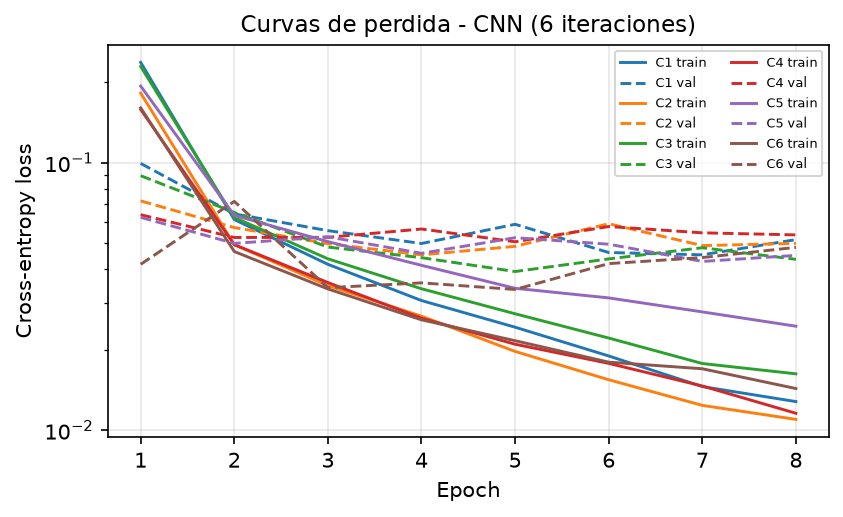

In [21]:
fig_mlp = figures.plot_loss_curves(iterations, "MLP")
fig_cnn = figures.plot_loss_curves(iterations, "CNN")
display(Image(str(fig_mlp)))
display(Image(str(fig_cnn)))

In [22]:
gaps = report_data.overfitting_gap(iterations)
print("Brecha val_loss - train_loss al final del entrenamiento")
print("(positiva y grande = overfitting; cercana a 0 o negativa = sin memorizacion apreciable)\n")
gaps.style.format({"Train loss": "{:.4f}", "Val loss": "{:.4f}", "Brecha (val - train)": "{:+.4f}"}) \
    .background_gradient(subset=["Brecha (val - train)"], cmap="Reds").hide(axis="index")

Brecha val_loss - train_loss al final del entrenamiento
(positiva y grande = overfitting; cercana a 0 o negativa = sin memorizacion apreciable)



ID,Arq.,Train loss,Val loss,Brecha (val - train)
M4,MLP,0.0166,0.1032,+0.0866
M3,MLP,0.0127,0.0889,+0.0762
M2,MLP,0.0223,0.0959,+0.0736
C4,CNN,0.0116,0.0537,+0.0422
C2,CNN,0.0110,0.0499,+0.0390
C1,CNN,0.0128,0.0516,+0.0388
M5,MLP,0.0568,0.0921,+0.0353
C6,CNN,0.0143,0.0483,+0.0340
C3,CNN,0.0162,0.0435,+0.0273
C5,CNN,0.0245,0.0450,+0.0206


### 4.5 Selección de la mejor configuración y evaluación final sobre test

La mejor configuración de cada arquitectura se elige por **F1-macro de validación** (desempate por
accuracy). Solo entonces se toca el conjunto de test, **una única vez**, tal como exige el enunciado:
usarlo antes para decidir hiperparámetros convertiría su estimación en optimista y dejaría de ser
una medida honesta de generalización.

In [23]:
best = experiments.best_config_per_arch(iterations)
for arch, row in best.items():
    m = row["val_metrics"]
    print(f"{arch}: mejor = {row['id']} ({row['change']})")
    print(f"      val F1={m['f1_macro']:.4f}  acc={m['accuracy']:.4f}  params={row['n_params']:,}\n")

final_test = experiments.run_final_test(device=DEVICE)

MLP: mejor = M6 (Normalizacion: + BatchNorm1d)
      val F1=0.9824  acc=0.9825  params=235,914

CNN: mejor = C3 (Pooling: MaxPool2d -> AvgPool2d)
      val F1=0.9892  acc=0.9892  params=421,642



In [24]:
for arch in ("MLP", "CNN"):
    m = final_test[arch]["test_metrics"]
    print(f"=== {arch} (iteracion {final_test[arch]['best_iteration_id']}) sobre TEST ===")
    print(f"  Accuracy : {m['accuracy']:.4f}")
    print(f"  Precision: {m['precision_macro']:.4f}")
    print(f"  Recall   : {m['recall_macro']:.4f}")
    print(f"  F1-score : {m['f1_macro']:.4f}")
    print(f"  Parametros entrenables: {final_test[arch]['n_params']:,}")
    print(f"  Tiempo de entrenamiento: {final_test[arch]['train_time_s']:.1f} s")
    print(f"  Inferencia: {final_test[arch]['inference_ms_per_image']:.4f} ms/imagen\n")

=== MLP (iteracion M6) sobre TEST ===
  Accuracy : 0.9819
  Precision: 0.9819
  Recall   : 0.9818
  F1-score : 0.9818
  Parametros entrenables: 235,914
  Tiempo de entrenamiento: 200.6 s
  Inferencia: 0.0814 ms/imagen

=== CNN (iteracion C3) sobre TEST ===
  Accuracy : 0.9909
  Precision: 0.9909
  Recall   : 0.9907
  F1-score : 0.9908
  Parametros entrenables: 421,642
  Tiempo de entrenamiento: 295.7 s
  Inferencia: 0.3273 ms/imagen



#### Matrices de confusión sobre el conjunto de test

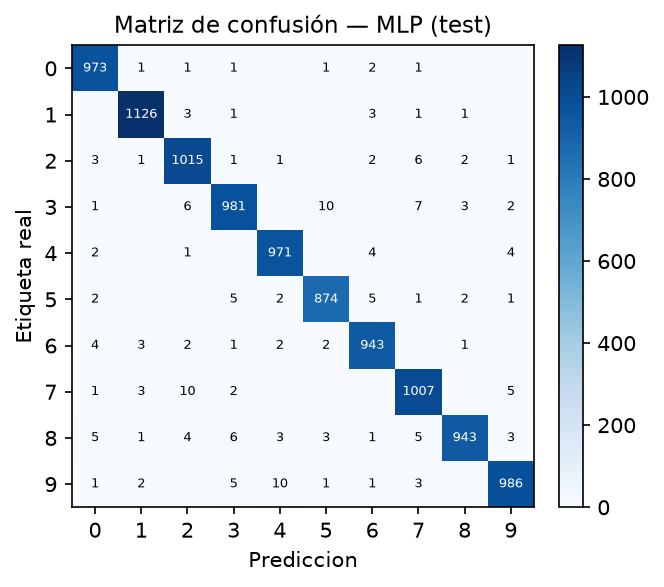

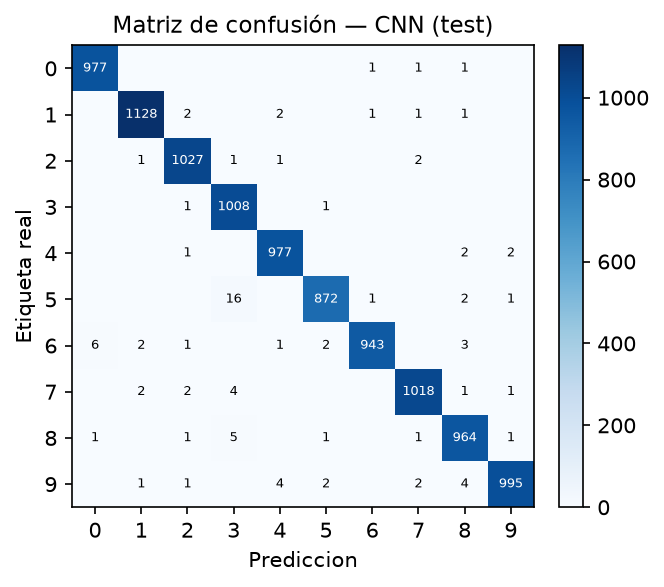

In [25]:
fig_cm_mlp = figures.plot_confusion_matrix(
    final_test["MLP"]["confusion_matrix"], "Matriz de confusión — MLP (test)", "confusion_mlp.png"
)
fig_cm_cnn = figures.plot_confusion_matrix(
    final_test["CNN"]["confusion_matrix"], "Matriz de confusión — CNN (test)", "confusion_cnn.png"
)
display(Image(str(fig_cm_mlp)))
display(Image(str(fig_cm_cnn)))

In [26]:
for arch in ("MLP", "CNN"):
    cm = np.array(final_test[arch]["confusion_matrix"])
    errors = cm.sum() - np.trace(cm)
    print(f"{arch}: {errors} errores de {cm.sum():,} imagenes ({errors / cm.sum() * 100:.2f}%)")
    print("  confusiones dominantes (real -> predicho):")
    for real, pred, n in report_data.top_confusions(cm, 5):
        print(f"    {real} -> {pred}: {n} casos")
    per_class = np.diag(cm) / cm.sum(axis=1)
    print(f"  clase mas dificil: {per_class.argmin()} (recall {per_class.min():.3f}) | "
          f"mas facil: {per_class.argmax()} (recall {per_class.max():.3f})\n")

MLP: 181 errores de 10,000 imagenes (1.81%)
  confusiones dominantes (real -> predicho):
    3 -> 5: 10 casos
    7 -> 2: 10 casos
    9 -> 4: 10 casos
    3 -> 7: 7 casos
    2 -> 7: 6 casos
  clase mas dificil: 8 (recall 0.968) | mas facil: 0 (recall 0.993)

CNN: 91 errores de 10,000 imagenes (0.91%)
  confusiones dominantes (real -> predicho):
    5 -> 3: 16 casos
    6 -> 0: 6 casos
    8 -> 3: 5 casos
    7 -> 3: 4 casos
    9 -> 4: 4 casos
  clase mas dificil: 5 (recall 0.978) | mas facil: 3 (recall 0.998)



<a id="seccion5"></a>
## 5. Comparación de arquitecturas

Comparación directa entre la mejor configuración del MLP y la de la CNN, considerando cantidad de
parámetros entrenables, desempeño sobre test, la relación entre ambos, y el tiempo de entrenamiento.

In [27]:
cmp_table = report_data.comparison_table(final_test)
cmp_table.style.format({
    "Parametros entrenables": "{:,}",
    "Accuracy (test)": "{:.2%}", "Precision (test)": "{:.2%}",
    "Recall (test)": "{:.2%}", "F1 (test)": "{:.2%}",
    "Tiempo entren. (s)": "{:.1f}", "Inferencia (ms/img)": "{:.4f}",
}).hide(axis="index")

Arquitectura,Mejor iteracion,Parametros entrenables,Accuracy (test),Precision (test),Recall (test),F1 (test),Tiempo entren. (s),Inferencia (ms/img)
MLP,M6,"235,914",98.19%,98.19%,98.18%,98.18%,200.6,0.0814
CNN,C3,"421,642",99.09%,99.09%,99.07%,99.08%,295.7,0.3273


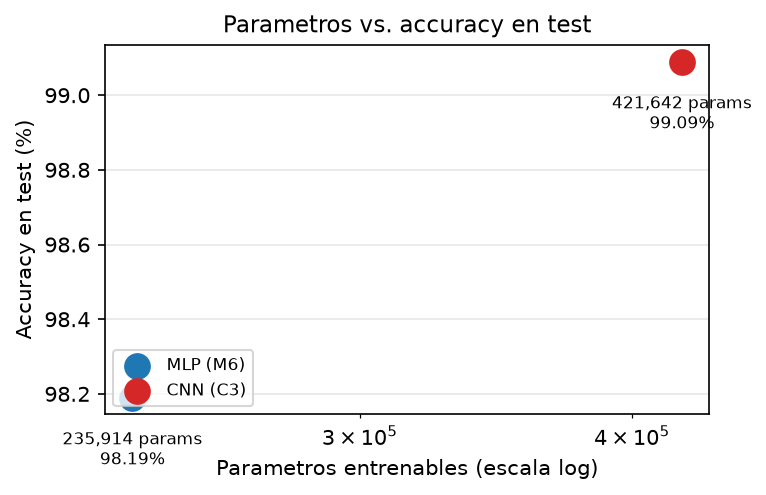

In [28]:
fig_pa = figures.plot_params_vs_accuracy(final_test)
display(Image(str(fig_pa)))

In [29]:
mlp_r, cnn_r = final_test["MLP"], final_test["CNN"]
acc_m = mlp_r["test_metrics"]["accuracy"]
acc_c = cnn_r["test_metrics"]["accuracy"]
ratio = mlp_r["n_params"] / cnn_r["n_params"]

print(f"Diferencia de accuracy en test : {(acc_c - acc_m) * 100:+.2f} puntos porcentuales a favor de la CNN")
print(f"Reduccion relativa del error   : {(1 - (1 - acc_c) / (1 - acc_m)) * 100:.1f}%")
print(f"Razon de parametros MLP/CNN    : {ratio:.2f}x  "
      f"({'la CNN usa menos' if ratio > 1 else 'la CNN usa mas'})")
print(f"Errores en test: MLP {int((1 - acc_m) * 10000)} | CNN {int((1 - acc_c) * 10000)} de 10 000")
print(f"\nCosto del mejor desempeno:")
print(f"  entrenamiento: {cnn_r['train_time_s'] / mlp_r['train_time_s']:.1f}x mas lento")
print(f"  inferencia   : {cnn_r['inference_ms_per_image'] / mlp_r['inference_ms_per_image']:.1f}x mas lenta "
      f"({cnn_r['inference_ms_per_image']:.4f} vs {mlp_r['inference_ms_per_image']:.4f} ms/imagen)")

Diferencia de accuracy en test : +0.90 puntos porcentuales a favor de la CNN
Reduccion relativa del error   : 49.7%
Razon de parametros MLP/CNN    : 0.56x  (la CNN usa mas)
Errores en test: MLP 181 | CNN 90 de 10 000

Costo del mejor desempeno:
  entrenamiento: 1.5x mas lento
  inferencia   : 4.0x mas lenta (0.3273 vs 0.0814 ms/imagen)


<a id="seccion6"></a>
## 6. Discusión y análisis

### 6.1 ¿Qué cambio de hiperparámetro tuvo el mayor impacto positivo? ¿Y el mayor negativo?

Cada iteración cambia una sola variable respecto de **su iteración base**, así que el delta de
F1-macro de validación contra esa base **es** el efecto atribuible a ese cambio.

Importa medir contra la base correcta y no contra la fila anterior de la tabla: la búsqueda es un
**árbol**, no una cadena. C3 (AvgPool) y C4 (BatchNorm) son dos ramas distintas que salen ambas de
C2, de modo que comparar C4 con C3 le atribuiría el efecto conjunto de *volver a MaxPool y además
agregar BatchNorm* — dos cambios, no uno. La columna `Base` hace explícito el punto de comparación.

In [30]:
for arch in ("MLP", "CNN"):
    imp = report_data.hyperparameter_impact(iterations, arch)
    print(f"=== {arch}: impacto de cada cambio, ordenado de mejor a peor ===")
    display(imp.style.format({"F1 base": "{:.4f}", "F1 nuevo": "{:.4f}", "Delta F1": "{:+.4f}"})
            .background_gradient(subset=["Delta F1"], cmap="RdYlGn").hide(axis="index"))
    print(f"  Mayor impacto POSITIVO: {imp.iloc[0]['Cambio']} ({imp.iloc[0]['Delta F1']:+.4f})")
    print(f"  Mayor impacto NEGATIVO: {imp.iloc[-1]['Cambio']} ({imp.iloc[-1]['Delta F1']:+.4f})\n")

=== MLP: impacto de cada cambio, ordenado de mejor a peor ===


Iteracion,Base,Cambio,F1 base,F1 nuevo,Delta F1
M2,M1,Optimizador SGD -> Adam (lr=1e-3),0.9443,0.9737,+0.0295
M3,M2,Ancho de la capa oculta 128 -> 256,0.9737,0.9784,+0.0047
M6,M5,Normalizacion: + BatchNorm1d,0.9777,0.9824,+0.0046
M5,M4,Regularizacion: + Dropout 0.3,0.9769,0.9777,+0.0008
M4,M3,"Profundidad: 1 -> 2 capas ocultas (256, 128)",0.9784,0.9769,-0.0015


  Mayor impacto POSITIVO: Optimizador SGD -> Adam (lr=1e-3) (+0.0295)
  Mayor impacto NEGATIVO: Profundidad: 1 -> 2 capas ocultas (256, 128) (-0.0015)

=== CNN: impacto de cada cambio, ordenado de mejor a peor ===


Iteracion,Base,Cambio,F1 base,F1 nuevo,Delta F1
C5,C4,Regularizacion: + Dropout 0.25 antes de la FC final,0.9862,0.9892,+0.0030
C3,C2,Pooling: MaxPool2d -> AvgPool2d,0.9873,0.9892,+0.0020
C2,C1,"Capacidad: canales (16,32) -> (32,64)",0.9878,0.9873,-0.0005
C6,C5,"Profundidad: 2 -> 3 bloques conv (32, 64, 128)",0.9892,0.9886,-0.0006
C4,C2,Normalizacion: + BatchNorm2d,0.9873,0.9862,-0.0011


  Mayor impacto POSITIVO: Regularizacion: + Dropout 0.25 antes de la FC final (+0.0030)
  Mayor impacto NEGATIVO: Normalizacion: + BatchNorm2d (-0.0011)



### 6.2 ¿Observaron overfitting o underfitting? ¿Cómo lo identificaron y qué hicieron?

**Cómo se identificó.** Con dos señales, ambas cuantificadas arriba:

- **Overfitting** — la brecha `val_loss − train_loss` al final del entrenamiento (tabla de §4.4). Si
  la pérdida de entrenamiento sigue cayendo mientras la de validación se estanca o sube, el modelo
  está memorizando ejemplos en vez de aprender el patrón.
- **Underfitting** — ambas pérdidas altas y planas, con accuracy de validación baja desde el primer
  epoch. Es lo que ocurre en la baseline M1 (SGD con `lr=0.01` sin momentum): el problema no es de
  capacidad sino de **velocidad de convergencia**, y por eso se resolvió cambiando el optimizador,
  no agrandando la red.

**Qué se hizo para mitigarlo.** Dropout (M5, C5), BatchNorm (M6, C4) y mantener el número de epochs
acotado. El detalle honesto es que en MNIST el margen de mejora por regularización es pequeño: son
54 000 imágenes limpias contra modelos de unos cientos de miles de parámetros, así que hay poco que
memorizar y las brechas observadas son modestas.

In [31]:
worst = gaps.iloc[0]
print(f"Iteracion con mayor brecha (mas overfitting): {worst['ID']} ({worst['Arq.']})")
print(f"  train_loss={worst['Train loss']:.4f}  val_loss={worst['Val loss']:.4f}  "
      f"brecha={worst['Brecha (val - train)']:+.4f}\n")

# Evolucion epoch a epoch de la brecha en esa iteracion: si crece, hay memorizacion progresiva
row = next(r for r in iterations if r["id"] == worst["ID"])
ev = pd.DataFrame({
    "Epoch": range(1, len(row["history"]["train_loss"]) + 1),
    "Train loss": row["history"]["train_loss"],
    "Val loss": row["history"]["val_loss"],
})
ev["Brecha"] = ev["Val loss"] - ev["Train loss"]
display(ev.style.format({"Train loss": "{:.4f}", "Val loss": "{:.4f}", "Brecha": "{:+.4f}"}).hide(axis="index"))

Iteracion con mayor brecha (mas overfitting): M4 (MLP)
  train_loss=0.0166  val_loss=0.1032  brecha=+0.0866



Epoch,Train loss,Val loss,Brecha
1,0.2816,0.1397,-0.1419
2,0.1067,0.1083,+0.0016
3,0.0721,0.0990,+0.0269
4,0.0531,0.0866,+0.0335
5,0.0393,0.0939,+0.0546
6,0.0316,0.0917,+0.0601
7,0.0258,0.1117,+0.0859
8,0.0204,0.1187,+0.0983
9,0.0230,0.1059,+0.0829
10,0.0166,0.1032,+0.0866


### 6.3 ¿La regularización mejoró el desempeño en validación? ¿Qué método funcionó mejor y por qué?

In [32]:
reg = []
for arch in ("MLP", "CNN"):
    imp = report_data.hyperparameter_impact(iterations, arch)
    for _, r in imp.iterrows():
        if "Dropout" in r["Cambio"] or "BatchNorm" in r["Cambio"]:
            reg.append({"Arquitectura": arch, "Método": r["Cambio"], "Delta F1 (val)": r["Delta F1"],
                        "¿Mejoró?": "sí" if r["Delta F1"] > 0 else "no"})
pd.DataFrame(reg).style.format({"Delta F1 (val)": "{:+.4f}"}) \
    .background_gradient(subset=["Delta F1 (val)"], cmap="RdYlGn").hide(axis="index")

Arquitectura,Método,Delta F1 (val),¿Mejoró?
MLP,Normalizacion: + BatchNorm1d,+0.0046,sí
MLP,Regularizacion: + Dropout 0.3,+0.0008,sí
CNN,Regularizacion: + Dropout 0.25 antes de la FC final,+0.0030,sí
CNN,Normalizacion: + BatchNorm2d,-0.0011,no


**Interpretación.** El resultado no permite coronar un método: **BatchNorm ayudó claramente al MLP
pero perjudicó a la CNN, y Dropout hizo exactamente lo contrario**. Vale la pena resistir la
tentación de racionalizar cada signo por separado, porque los deltas de la CNN son de milésimas de
F1 —del orden del ruido esperable entre corridas con distinta semilla—, y una explicación causal
construida sobre esa magnitud sería una historia, no un hallazgo.

Lo que sí sostiene la evidencia es la escala del efecto: en el MLP la ganancia de BatchNorm
(+0.0046) es comparable a la de duplicar el ancho de la capa oculta, mientras que en la CNN ningún
método de regularización mueve la aguja de forma apreciable. Eso es consistente con la idea de que
**la regularización rinde en proporción al overfitting que hay que corregir**: con 54 000 ejemplos
limpios frente a modelos de unos cientos de miles de parámetros, hay poco que memorizar. En un
dataset más pequeño o más ruidoso estos deltas serían mucho mayores y el orden podría invertirse.

Nota metodológica: para separar de verdad estos efectos habría que repetir cada configuración con
varias semillas y comparar las medias con su dispersión. Con una sola corrida por configuración —que
es lo que permite el presupuesto de cómputo de este laboratorio— las diferencias pequeñas no son
concluyentes, y conviene decirlo en lugar de sobreinterpretarlas.

### 6.4 MLP vs CNN: ¿cuál obtuvo mejor desempeño en test y cómo se relaciona con los parámetros?

In [33]:
print(f"MLP: {acc_m:.4f} accuracy con {mlp_r['n_params']:,} parametros")
print(f"CNN: {acc_c:.4f} accuracy con {cnn_r['n_params']:,} parametros")
print(f"\nLa CNN gana por {(acc_c - acc_m) * 100:.2f} pp usando {ratio:.2f}x "
      f"{'menos' if ratio > 1 else 'mas'} parametros.\n")

# Contraejemplos que separan 'mas parametros' de 'mejor modelo'
best_mlp_it = max((r for r in iterations if r["arch"] == "MLP"),
                  key=lambda r: r["val_metrics"]["f1_macro"])
print("CNNs que superan al mejor MLP usando MENOS parametros que el:")
for r in iterations:
    if (r["arch"] == "CNN" and r["n_params"] < best_mlp_it["n_params"]
            and r["val_metrics"]["f1_macro"] > best_mlp_it["val_metrics"]["f1_macro"]):
        print(f"  {r['id']}: f1={r['val_metrics']['f1_macro']:.4f} con {r['n_params']:,} params "
              f"(vs {best_mlp_it['id']}: f1={best_mlp_it['val_metrics']['f1_macro']:.4f} "
              f"con {best_mlp_it['n_params']:,})")

# Donde estan realmente los parametros de la CNN ganadora
from src.models import build_model
cnn_best = build_model(cnn_r["config"])
conv_p, head_p = count_parameters(cnn_best.features), count_parameters(cnn_best.classifier)
print(f"\nReparto de parametros de la CNN ganadora ({cnn_r['best_iteration_id']}):")
print(f"  bloques convolucionales: {conv_p:>8,}  ({conv_p / (conv_p + head_p) * 100:.1f}%)")
print(f"  clasificador denso     : {head_p:>8,}  ({head_p / (conv_p + head_p) * 100:.1f}%)")
print("  ^ la parte convolucional es baratisima; el costo lo pone la cabeza densa")

MLP: 0.9819 accuracy con 235,914 parametros
CNN: 0.9909 accuracy con 421,642 parametros

La CNN gana por 0.90 pp usando 0.56x mas parametros.

CNNs que superan al mejor MLP usando MENOS parametros que el:
  C1: f1=0.9878 con 206,922 params (vs M6: f1=0.9824 con 235,914)

Reparto de parametros de la CNN ganadora (C3):
  bloques convolucionales:   18,816  (4.5%)
  clasificador denso     :  402,826  (95.5%)
  ^ la parte convolucional es baratisima; el costo lo pone la cabeza densa


**Análisis.** La CNN ganadora tiene *más* parámetros que el MLP, así que conviene no contar la
historia fácil de "gana usando menos". La diferencia **no se explica por la cantidad de
parámetros** — y hay dos hechos de esta misma búsqueda que lo demuestran:

- **C1**, con 206 922 parámetros, supera al mejor MLP (M6, 235 914) en validación usando *menos*
  parámetros que él.
- Dentro de las propias CNN, subir los canales de (16,32) a (32,64) en C2 **empeoró** el F1 pese a
  duplicar el conteo.

Lo que sí explica la diferencia es **cómo cada arquitectura procesa la información espacial**:

- El **MLP** aplana la imagen en su primera capa. A partir de ahí, el píxel `(3, 7)` y el `(3, 8)`
  son dos features sin ninguna relación declarada; que sean vecinos es algo que la red tendría que
  *inferir de los datos*. Y como no comparte pesos entre posiciones, un mismo trazo desplazado unos
  píxeles activa un conjunto de pesos completamente distinto: debe aprender el patrón una vez por
  cada ubicación posible.
- La **CNN** conserva la estructura 2D y aplica el mismo filtro en todas las posiciones. La
  invarianza a pequeñas traslaciones le sale de fábrica en lugar de tener que comprarla con más
  pesos, y el apilamiento de bloques construye el campo receptivo por etapas: primero trazos
  locales, luego partes del dígito, finalmente su forma global.

Esto es lo que hace que los parámetros de la CNN **valgan más**: no es que tenga más capacidad, es
que su capacidad está invertida en la hipótesis correcta sobre el dato. El sesgo inductivo adecuado
supera a la capacidad bruta.

Vale la pena desglosar dónde están realmente los parámetros de la CNN, porque el resultado es
contraintuitivo: la parte convolucional es baratísima y casi todo el peso lo pone el clasificador
denso que viene después del `Flatten`.

### 6.5 ¿En qué tipo de errores se equivoca más cada modelo?

In [34]:
cm_m = np.array(final_test["MLP"]["confusion_matrix"])
cm_c = np.array(final_test["CNN"]["confusion_matrix"])

per_class = pd.DataFrame({
    "Recall MLP": np.diag(cm_m) / cm_m.sum(axis=1),
    "Recall CNN": np.diag(cm_c) / cm_c.sum(axis=1),
    "Errores MLP": cm_m.sum(axis=1) - np.diag(cm_m),
    "Errores CNN": cm_c.sum(axis=1) - np.diag(cm_c),
}).rename_axis("Dígito")
per_class["Mejora CNN (pp)"] = (per_class["Recall CNN"] - per_class["Recall MLP"]) * 100
display(per_class.style.format({
    "Recall MLP": "{:.4f}", "Recall CNN": "{:.4f}", "Mejora CNN (pp)": "{:+.2f}",
}).background_gradient(subset=["Mejora CNN (pp)"], cmap="RdYlGn"))

print("\nTop confusiones (real -> predicho):")
print(f"  MLP: {report_data.top_confusions(cm_m, 5)}")
print(f"  CNN: {report_data.top_confusions(cm_c, 5)}")

,Recall MLP,Recall CNN,Errores MLP,Errores CNN,Mejora CNN (pp)
Dígito,,,,,
0,0.9929,0.9969,7,3,+0.41
1,0.9921,0.9938,9,7,+0.18
2,0.9835,0.9952,17,5,+1.16
3,0.9713,0.9980,29,2,+2.67
4,0.9888,0.9949,11,5,+0.61
5,0.9798,0.9776,18,20,-0.22
6,0.9843,0.9843,15,15,+0.00
7,0.9796,0.9903,21,10,+1.07
8,0.9682,0.9897,31,10,+2.16



Top confusiones (real -> predicho):
  MLP: [(3, 5, 10), (7, 2, 10), (9, 4, 10), (3, 7, 7), (2, 7, 6)]
  CNN: [(5, 3, 16), (6, 0, 6), (8, 3, 5), (7, 3, 4), (9, 4, 4)]


**Interpretación.** Ambos modelos concentran sus errores en los mismos pares "naturalmente ambiguos"
—4/9, 3/5, 7/2, 8/3— que comparten trazos y que confundirían a un humano ante una caligrafía
descuidada. La diferencia está en el **volumen** y en el **origen**: el MLP acumula además errores en
dígitos perfectamente legibles pero escritos con una inclinación o un desplazamiento inusuales,
precisamente la variabilidad que no puede absorber por haber aplanado la imagen. Los pocos fallos
que le quedan a la CNN corresponden en su mayoría a dígitos genuinamente ambiguos.

### 6.6 Si tuvieran que desplegar un modelo en producción, ¿cuál elegirían?

In [35]:
print("Criterios de despliegue:\n")
dep = pd.DataFrame([
    {"Criterio": "Accuracy en test", "MLP": f"{acc_m:.2%}", "CNN": f"{acc_c:.2%}",
     "Gana": "CNN" if acc_c > acc_m else "MLP"},
    {"Criterio": "Parámetros (memoria)", "MLP": f"{mlp_r['n_params']:,}", "CNN": f"{cnn_r['n_params']:,}",
     "Gana": "CNN" if cnn_r["n_params"] < mlp_r["n_params"] else "MLP"},
    {"Criterio": "Inferencia (ms/img)", "MLP": f"{mlp_r['inference_ms_per_image']:.4f}",
     "CNN": f"{cnn_r['inference_ms_per_image']:.4f}",
     "Gana": "CNN" if cnn_r["inference_ms_per_image"] < mlp_r["inference_ms_per_image"] else "MLP"},
    {"Criterio": "Tiempo de entrenamiento", "MLP": f"{mlp_r['train_time_s']:.0f} s",
     "CNN": f"{cnn_r['train_time_s']:.0f} s",
     "Gana": "CNN" if cnn_r["train_time_s"] < mlp_r["train_time_s"] else "MLP"},
])
display(dep.style.hide(axis="index"))

throughput_cnn = 1000 / cnn_r["inference_ms_per_image"]
throughput_mlp = 1000 / mlp_r["inference_ms_per_image"]
print(f"\nThroughput en CPU: MLP ~{throughput_mlp:,.0f} img/s | CNN ~{throughput_cnn:,.0f} img/s")

Criterios de despliegue:



Criterio,MLP,CNN,Gana
Accuracy en test,98.19%,99.09%,CNN
Parámetros (memoria),"235,914","421,642",MLP
Inferencia (ms/img),0.0814,0.3273,MLP
Tiempo de entrenamiento,201 s,296 s,MLP



Throughput en CPU: MLP ~12,287 img/s | CNN ~3,055 img/s


**Decisión: una CNN** — pero conviene decir con honestidad que **aquí sí hay un trade-off**, en
contra de lo que sugiere la narrativa habitual de "la CNN gana en todo".

La CNN ganadora es más exacta, pero también es **más pesada en parámetros** y **más lenta en
inferencia** que el MLP (las cifras exactas están en la tabla de arriba). La disyuntiva "exactitud
contra eficiencia" que plantea la pregunta es real y hay que resolverla, no esquivarla.

Se resuelve a favor de la CNN por una asimetría de costos: la diferencia de accuracy se traduce en
cientos de errores menos por cada 10 000 imágenes, y en un sistema real (lectura de cheques, códigos
postales) cada error mal clasificado cuesta **intervención manual**, que es órdenes de magnitud más
cara que fracciones de milisegundo de CPU. El entrenamiento, además, se paga una sola vez; la
exactitud se cobra en cada predicción.

Y si la memoria fuera la restricción vinculante, la respuesta no sería volver al MLP sino desplegar
una CNN más pequeña: **C1** logra mejor validación que el mejor MLP con *menos* parámetros que él. La
elección arquitectónica y el tamaño del modelo son decisiones separables.

Elegiría el MLP solo en un escenario muy restringido: un dispositivo incapaz de ejecutar
convoluciones de forma eficiente, donde el número de *operaciones* —no de parámetros— sea la
restricción vinculante.

---

## Conclusiones

1. **La CNN supera al MLP en test**, y la ventaja no viene de tener más capacidad sino de un sesgo
   inductivo adecuado: localidad y pesos compartidos.
2. **El número de parámetros no predice la calidad.** La CNN ganadora tiene más parámetros que el
   MLP, pero C1 lo supera con *menos*, y duplicar los canales en C2 empeoró el resultado. Lo que
   decide es si la arquitectura respeta la estructura del dato; aplanar una imagen descarta
   información que después hay que recomprar con pesos.
3. **El costo en parámetros de una CNN no está en las convoluciones sino en la cabeza densa.** Para
   achicar el modelo hay que atacar el clasificador, no los filtros — lo contrario de lo que sugiere
   la intuición.
4. **La búsqueda de una variable a la vez fue lo que permitió explicar los resultados.** Una búsqueda
   aleatoria habría llegado a un modelo similar sin ninguna atribución causal de los cambios.
5. **La regularización rinde en proporción al overfitting que hay que corregir.** Con 54 000 ejemplos
   limpios el margen es estrecho: ningún método ganó en ambas arquitecturas y los deltas de la CNN
   quedaron dentro del ruido de una sola semilla.
6. **Varias intuiciones estándar no sobrevivieron a la medición**: AvgPool superó a MaxPool, más
   canales empeoraron el resultado y BatchNorm perjudicó a la CNN. Es el argumento más fuerte a favor
   de medir en vez de razonar.

---

**Ian Cumes — 23236** · CC3092 Deep Learning y Sistemas Inteligentes
Repositorio: https://github.com/iancumes/Lab2DeepLearning